# EDA-Schema Dataset Analysis

This notebook analyzes sample data from the **EDA-Schema open dataset (version 2)**. The dataset is designed as a general resource for analysis and machine learning and is publicly available [here](https://drive.google.com/drive/folders/1B3rBvbnviBrKw1aLRpv7e1pEXSCy_vLQ?usp=sharing). Below are the key details:

### Dataset Specifications:
- **Physical Design Toolset**: OpenROAD  
- **Design PDKs**:
  - Nangate 45 nm
  - SkyWater 130 nm
  - ASAP7 7 nm
  - IHP SG13G2 130 nm  
- **Flow stages (OpenROAD stage naming used by the schema)**:
  - floorplan, global_place, place_resize, detailed_place, cts, global_route, detailed_route, final

V2 does not use fixed single values for latency and delays across the entire dataset. Instead, constraints are defined relative to the target clock period, and the dataset is expanded via parameter sweeps.

- **Barely Pass and Barely Fail definition** using Slack to Clock Period Ratio (SCPR):
  * Barely Fail: SCPR in (-10%, 0%)
  * Barely Pass: SCPR in (0%, +10%) 
- **Baseline operating point defaults**
  * Aspect ratio fixed at 1.0
  * Placement density assumed uniform
  * Core utilization: 40% for ASAP7 and NG45, 30% for SKY130 and IHP130 
- **Clocking and IO constraints**
  * Input and output delays: 20% of target clock period
  * Clock latency: 1% of target clock period, capped at 50 ps
  * Clock uncertainty: 5% of clock period, capped at 250 ps 
- **Parameter sweeps used to expand the dataset**
  * Target clock periods: {0.8 x BF, BF, BP, 1.2 x BP}
  * Aspect ratio: {0.5, 1.0, 1.5}
  * Core utilization ranges depend on PDK
  * Placement density: uniform, 1.25x uniform, 1.5x uniform 

### Dataset Purpose:
The dataset focuses on circuit timing performance under two scenarios:  

The dataset is designed to support reproducible ML research by providing standardized representations and metrics across multiple physical design stages, with explicit support for timing, power, area, and routability analyses.

This ensures the data is suitable for timing-critical analysis and optimization tasks.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# Import EDA_schema library functions
from eda_schema.entity import DesignStages
from eda_schema.dataset import Dataset
from eda_schema.db import ParquetDB

# Define the dataset directory (adjust the path if needed)
DATASET_DIR = "../../../datasets/nangate45/nangate45_fullrun_combined"
dataset = Dataset(ParquetDB(DATASET_DIR))

## 1. Dataset Statistics

Analyze the general characteristics and diversity of circuits in the dataset.

In [2]:
# Load core dataset tables
print("Loading core dataset tables...")
design_flow_df = dataset.db.get_table_data("design_flows")
constraint_df = dataset.db.get_table_data("constraints")
netlist_df = dataset.db.get_table_data("netlists")
cell_metrics_df = dataset.db.get_table_data("cell_metrics")
area_metrics_df = dataset.db.get_table_data("area_metrics")
power_metrics_df = dataset.db.get_table_data("power_metrics")
timing_df = dataset.db.get_table_data("timing_metrics")

# Verify data loading
loaded_tables = [design_flow_df, constraint_df, netlist_df, cell_metrics_df, 
                 area_metrics_df, power_metrics_df, timing_df]
if all(not df.empty for df in loaded_tables):
    print("All core tables loaded successfully")
else:
    print("Some tables failed to load - analysis may be incomplete")

Loading core dataset tables...
All core tables loaded successfully


In [3]:
# Merge all data into comprehensive DataFrame
print("\nMerging dataset tables...")

df = (
    design_flow_df
    .merge(constraint_df, on=["flow_id"], how="inner")
    .merge(netlist_df, on=["flow_id"], how="inner")
    .merge(cell_metrics_df, on=["flow_id", "stage"], how="inner")
    .merge(area_metrics_df, on=["flow_id", "stage"], how="inner")
    .merge(power_metrics_df, on=["flow_id", "stage"], how="inner")
    .merge(timing_df, on=["flow_id", "stage"], how="inner")
)

print(f"- Merged DataFrame shape: {df.shape}")
print(f"- Unique flows: {df['flow_id'].nunique()}")
print(f"- Unique designs: {df['design'].nunique()}")
print(f"- Design stages: "+ ", ".join(df['stage'].unique()))


Merging dataset tables...
- Merged DataFrame shape: (15543, 54)
- Unique flows: 1944
- Unique designs: 18
- Design stages: floorplan, global_place, place_resized, detailed_place, cts, global_route, detailed_route, final


In [4]:
# Add derived columns for analysis
print("\nAdding derived analysis columns...")

# Clock period classification
df["clock_rank"] = df.groupby("design")["clock_period"].rank(method="dense", ascending=True)
rank_to_label = {1: "BF-", 2: "BF", 3: "BP", 4: "BP+"}
df["clock_class"] = df["clock_rank"].map(rank_to_label)
df["clock_class"] = pd.Categorical(df["clock_class"], categories=["BF-", "BF", "BP", "BP+"], ordered=True)

# Placement density classification
id_num = df["flow_id"].str.split("-").str[-1].astype(int)
df["place_density"] = np.where(id_num <= 60, 1.0, 
                              np.where(id_num <= 90, 1.25, 
                                     np.where(id_num <= 120, 1.5, 1.0)))

# Convert stage to ordered categorical
df['stage'] = df['stage'].astype(pd.CategoricalDtype(DesignStages.tolist(), ordered=True))

# Remove helper column
df = df.drop(columns=["clock_rank"])

print("- Derived columns added successfully")


Adding derived analysis columns...
- Derived columns added successfully


In [5]:
# Extract final stage summary
summary_columns = [
    "flow_id", "design", "clock_period", "clock_class", "aspect_ratio", 
    "core_utilization", "place_density", "no_of_inputs", "no_of_outputs", 
    "no_of_nets", "no_of_cells", "no_of_sequential_cells", "no_of_buffers", 
    "no_of_inverters", "no_of_fillers", "no_of_tap_cells"
]

summary_df = df[df.stage == "final"][summary_columns].set_index("flow_id").sort_index()

# Convert numeric columns to float for consistency
for col in summary_df.columns:
    if pd.api.types.is_numeric_dtype(summary_df[col]):
        summary_df[col] = summary_df[col].astype(float)

print(f"\nFinal Stage Summary")
print(f"Shape: {summary_df.shape}")
print("\nSample data:")
display(summary_df.head())

print("\nBasic statistics:")
display(summary_df.describe().round(2))


Final Stage Summary
Shape: (1941, 15)

Sample data:


,design,clock_period,clock_class,aspect_ratio,core_utilization,place_density,no_of_inputs,no_of_outputs,no_of_nets,no_of_cells,no_of_sequential_cells,no_of_buffers,no_of_inverters,no_of_fillers,no_of_tap_cells
flow_id,,,,,,,,,,,,,,,
ac97_ctrl-000001,ac97_ctrl,0.72,BP+,0.5,30.0,1.0,84.0,48.0,7916.0,22096.0,2211.0,830.0,344.0,14172.0,374.0
ac97_ctrl-000002,ac97_ctrl,0.72,BP+,0.5,40.0,1.0,84.0,48.0,7865.0,19854.0,2211.0,789.0,299.0,12016.0,326.0
ac97_ctrl-000003,ac97_ctrl,0.72,BP+,0.5,50.0,1.0,84.0,48.0,7837.0,17474.0,2211.0,740.0,334.0,9650.0,290.0
ac97_ctrl-000004,ac97_ctrl,0.72,BP+,1.0,30.0,1.0,84.0,48.0,7986.0,22979.0,2211.0,923.0,354.0,14952.0,530.0
ac97_ctrl-000005,ac97_ctrl,0.72,BP+,1.0,40.0,1.0,84.0,48.0,7964.0,20166.0,2211.0,911.0,308.0,12197.0,381.0



Basic statistics:


,clock_period,aspect_ratio,core_utilization,place_density,no_of_inputs,no_of_outputs,no_of_nets,no_of_cells,no_of_sequential_cells,no_of_buffers,no_of_inverters,no_of_fillers,no_of_tap_cells
count,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00
mean,1.16,1.00,40.01,1.15,103.30,78.53,9167.37,20162.99,1454.20,634.35,720.44,11440.49,334.65
std,0.65,0.41,8.16,0.19,88.66,65.69,13496.08,29393.31,2486.51,738.54,1885.73,17159.17,367.03
min,0.26,0.50,30.00,1.00,14.00,9.00,347.00,703.00,64.00,38.00,8.00,330.00,38.00
25%,0.60,0.50,30.00,1.00,19.00,18.00,821.00,1865.00,129.00,91.00,67.00,1104.00,92.00
50%,1.00,1.00,40.00,1.00,84.00,48.00,3179.00,7433.00,361.00,372.00,151.00,4357.00,186.00
75%,1.65,1.50,50.00,1.25,162.00,129.00,10543.00,22979.00,1740.00,785.00,436.00,12858.00,403.00
max,3.00,1.50,50.00,1.50,260.00,215.00,52890.00,121556.00,10544.00,3835.00,8504.00,76749.00,1700.00


## 2. Power, Performance, Area (PPA) Analysis

Analyze the distribution of key quality-of-result (QoR) metrics across different circuit designs.

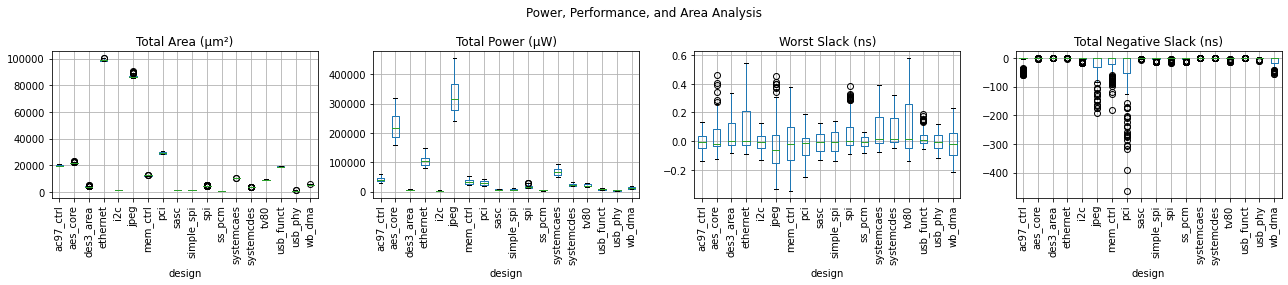

In [6]:
# Plot the distribution of total area, power, and timing metrics.
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
ppa_columns = ["total_area", "total_power", "worst_slack", "total_negative_slack"]
ppa_labels = ["Total Area (µm²)", "Total Power (µW)", "Worst Slack (ns)", "Total Negative Slack (ns)"]

for i, col in enumerate(ppa_columns):
    df[df.stage == "final"].boxplot(column=[col], by='design', ax=axes[i])
    axes[i].yaxis.get_major_formatter().set_scientific(False)
    axes[i].set_title(ppa_labels[i])
    for label in axes[i].get_xticklabels():
        label.set_rotation(90)

plt.suptitle('Power, Performance, and Area Analysis')
plt.tight_layout()
plt.show()

In [7]:
# Overall PPA statistics (across all designs)
final_stage_data = df[df.stage == "final"]
ppa_stats = final_stage_data[ppa_columns]

overall_stats = pd.DataFrame({
    "count": ppa_stats.count(),
    "mean": ppa_stats.mean(),
    "std": ppa_stats.std(),
    "min": ppa_stats.min(),
    "25%": ppa_stats.quantile(0.25),
    "50%": ppa_stats.quantile(0.5),
    "75%": ppa_stats.quantile(0.75),
    "max": ppa_stats.max(),
    "range": ppa_stats.max() - ppa_stats.min(),
    "cv": ppa_stats.std() / ppa_stats.mean()  # coefficient of variation
}).round(4)

# Format for display
def format_number(x, decimals=2):
    """Format numbers for display."""
    if isinstance(x, (int, float)):
        if abs(x) >= 1e6:
            return f"{x/1e6:.{decimals}f}M"
        elif abs(x) >= 1e3:
            return f"{x/1e3:.{decimals}f}K"
        else:
            return f"{x:.{decimals}f}"
    return str(x)
display_df = overall_stats.copy()
for col in display_df.columns:
    if col != "count":
        display_df[col] = display_df[col].apply(lambda x: format_number(x, 2))

print("Overall PPA Metrics Statistics (Final Stage)")
display(display_df)

# Summary insights
print("\nKey Insights:")
print(f"• Total analyzed flows: {len(final_stage_data)}")
print(f"• Designs with timing violations: {(final_stage_data['worst_slack'] < 0).sum()}")
print(f"• Percentage of timing-critical designs: {((final_stage_data['worst_slack'] < 0).sum() / len(final_stage_data) * 100):.1f}%")
print(f"• Most variable metric (CV): {overall_stats['cv'].idxmax()} ({overall_stats['cv'].max():.3f})")
print(f"• Least variable metric (CV): {overall_stats['cv'].idxmin()} ({overall_stats['cv'].min():.3f})")

Overall PPA Metrics Statistics (Final Stage)


,count,mean,std,min,25%,50%,75%,max,range,cv
total_area,1941,18.23K,27.53K,723.00,1.56K,5.60K,19.41K,100.50K,99.78K,1.51
total_power,1941,52.69K,87.95K,2.23K,6.09K,17.50K,46.10K,456.00K,453.77K,1.67
worst_slack,1941,0.03,0.14,-0.35,-0.04,-0.00,0.07,0.58,0.93,5.54
total_negative_slack,1941,-8.67,34.07,-463.93,-0.84,-0.00,0.00,0.00,463.93,-3.93



Key Insights:
• Total analyzed flows: 1941
• Designs with timing violations: 999
• Percentage of timing-critical designs: 51.5%
• Most variable metric (CV): worst_slack (5.538)
• Least variable metric (CV): total_negative_slack (-3.931)


## 3. Timing Analysis

Deep dive into timing path characteristics, slack violations, and critical path analysis.

In [8]:
# Load timing paths data
print("Loading timing paths data...")
timing_path_df = dataset.db.get_table_data("timing_paths", stage="final", path_type="setup")

if not timing_path_df.empty:
    # Extract worst slack per flow
    def get_min_slack(group):
        return group.loc[group['slack'].idxmin()]
    
    slack_df = timing_path_df.groupby("flow_id").apply(get_min_slack).drop("flow_id", axis=1)
    
    # Add design information
    design_flow_subset = design_flow_df[["flow_id", "design"]].set_index("flow_id")
    slack_df = pd.concat([slack_df, design_flow_subset], axis=1)
    
    # Create timing summary metrics
    timing_summary_df = pd.DataFrame(index=slack_df.index)
    timing_summary_df["design"] = slack_df.design
    timing_summary_df["total_paths"] = timing_path_df.groupby(["flow_id"]).size()
    timing_summary_df["violated_paths"] = timing_path_df[timing_path_df.slack < 0].groupby(["flow_id"]).size()
    timing_summary_df["worst_slack"] = slack_df["slack"]
    timing_summary_df["tns"] = timing_path_df[timing_path_df.slack < 0].groupby(["flow_id"]).sum().slack
    timing_summary_df.fillna(0, inplace=True)
    timing_summary_df["violated_paths"] = timing_summary_df["violated_paths"].astype(int)
    
    print("✅ Timing analysis data prepared")
    print(f"Total timing paths analyzed: {len(timing_path_df):,}")
    print(f"Flows with timing data: {len(timing_summary_df)}")
    
else:
    print("❌ No timing paths data available")
    timing_summary_df = pd.DataFrame()

Loading timing paths data...
✅ Timing analysis data prepared
Total timing paths analyzed: 2,284,149
Flows with timing data: 1944


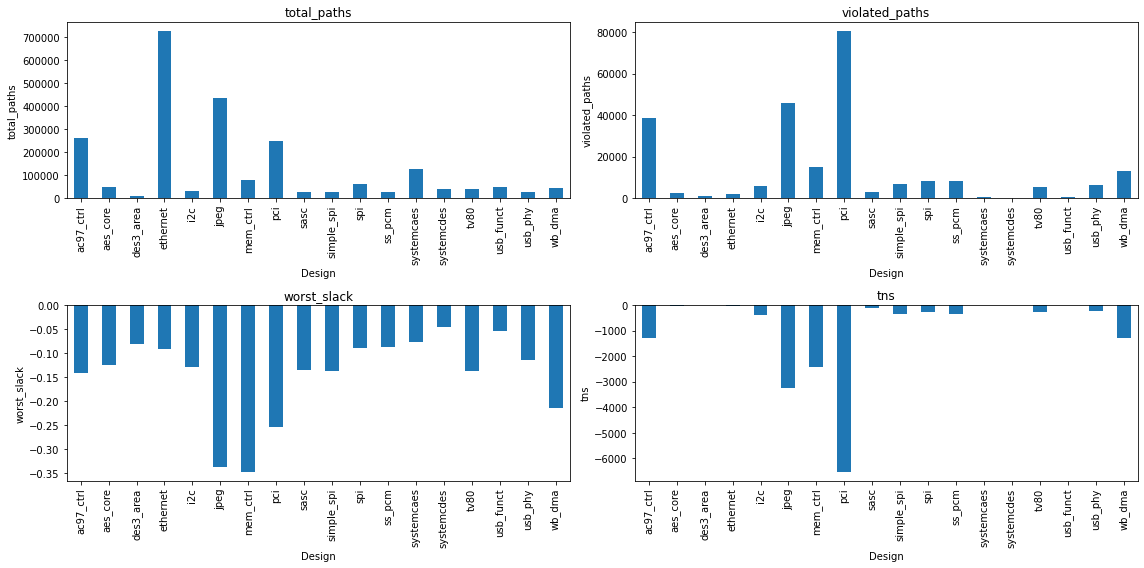

In [9]:
design_summary_df = (
    timing_summary_df
    .groupby("design")
    .agg({
        "total_paths": "sum",
        "violated_paths": "sum",
        "worst_slack": "min",
        "tns": "sum",
    })
)

# Plot timing analysis metrics grouped by design
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
metrics = [
    "total_paths",
    "violated_paths",
    "worst_slack",
    "tns",
]

for ax, metric in zip(axes, metrics):
    design_summary_df[metric].plot(kind="bar", ax=ax, title=metric)
    ax.set_ylabel(metric)
    ax.set_xlabel("Design")

plt.tight_layout()
plt.show()

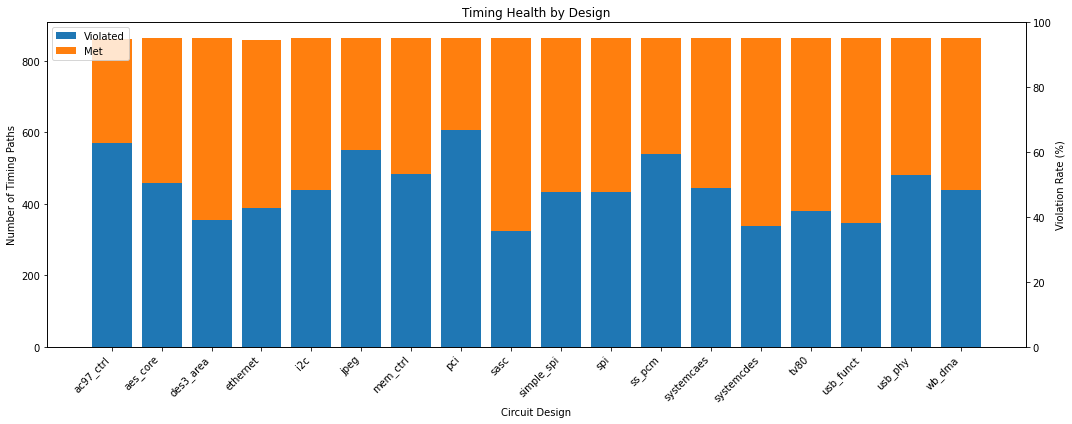

In [10]:
# Aggregate timing health by design and sort by design name
timing_health_df = (
    df.assign(
        met=df["worst_slack"] >= 0,
        violated=df["worst_slack"] < 0
    )
    .groupby("design")
    .agg(
        met=("met", "sum"),
        violated=("violated", "sum"),
        total=("worst_slack", "count")
    )
    .sort_index()
)

# X positions
x = np.arange(len(timing_health_df))

# Create figure with twin y-axis
fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()

# Stacked bars for counts (left axis)
ax1.bar(x, timing_health_df["violated"], label="Violated")
ax1.bar(
    x,
    timing_health_df["met"],
    bottom=timing_health_df["violated"],
    label="Met"
)

# Left axis formatting
ax1.set_xticks(x)
ax1.set_xticklabels(timing_health_df.index, rotation=45, ha="right")
ax1.set_xlabel("Circuit Design")
ax1.set_ylabel("Number of Timing Paths")
ax1.set_title("Timing Health by Design")
ax1.legend(loc="upper left")

# Right axis formatting only
ax2.set_ylabel("Violation Rate (%)")
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [11]:

total_paths = timing_health_df["total"].sum()
total_violated = timing_health_df["violated"].sum()
overall_violation_rate = (total_violated / total_paths * 100).round(1)

perfect_designs = (timing_health_df["violated"] == 0).sum()

# Per-design violation rate only for summary logic
per_design_rate = timing_health_df["violated"] / timing_health_df["total"] * 100
most_critical_design = per_design_rate.idxmax()
most_critical_rate = per_design_rate.max().round(1)

print("Timing Summary:")
print(f"Total paths: {total_paths:,}")
print(f"Violations: {total_violated:,} ({overall_violation_rate:.1f}%)")
print(f"• Designs with zero violations: {perfect_designs}/{len(timing_health_df)}")
print(f"• Most critical design: {most_critical_design} ({most_critical_rate:.1f}% violations)")

Timing Summary:
Total paths: 15,543
Violations: 8,002 (51.5%)
• Designs with zero violations: 0/18
• Most critical design: pci (70.3% violations)


## 4. Inter-Stage Metric Evolution

Analyze how key metrics evolve through the physical design flow stages.

<ipython-input-12-e1e09504d873>:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df[df.design == "ac97_ctrl"].groupby("stage")[metric].mean()
<ipython-input-12-e1e09504d873>:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df[df.design == "ac97_ctrl"].groupby("stage")[metric].mean()
<ipython-input-12-e1e09504d873>:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df[df.design == "ac97_ctrl"].gro

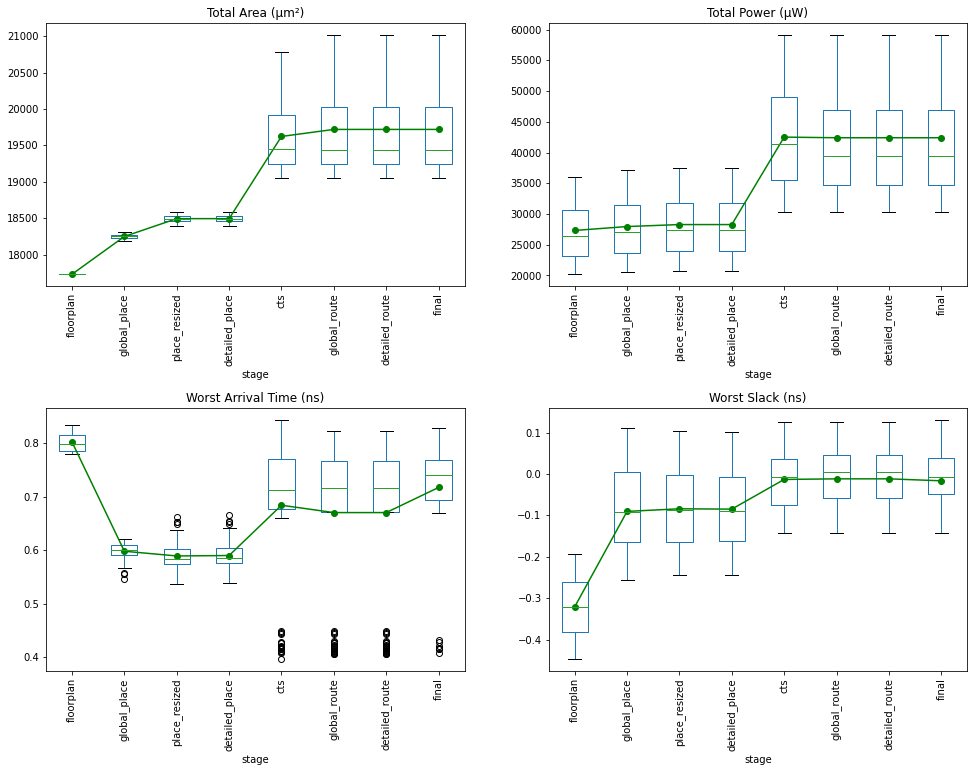

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
fig.tight_layout(pad=10)

evolution_metrics = ["total_area", "total_power", "worst_arrival_time", "worst_slack"]
metric_labels = ["Total Area (µm²)", "Total Power (µW)", "Worst Arrival Time (ns)", "Worst Slack (ns)"]

for i, metric in enumerate(evolution_metrics):
    df[df.design == "ac97_ctrl"].boxplot(column=[metric], by="stage", grid=False, ax=axes[i], showfliers=True)
    means = df[df.design == "ac97_ctrl"].groupby("stage")[metric].mean()
    x_positions = list(range(1, len(means) + 1))
    axes[i].plot(x_positions, means, marker='o', color='green')
    axes[i].set_title(metric_labels[i])
    for label in axes[i].get_xticklabels():
        label.set_rotation(90)

fig.suptitle('')
plt.show()

In [13]:
# Overall evolution patterns across all designs
print("Analyzing evolution patterns across all designs...")

# Create evolution summary
evolution_summary = []

for metric in evolution_metrics:
    metric_data = df.groupby(["design", "stage"], observed=False)[metric].mean().reset_index()
    
    # Calculate stage-to-stage changes
    metric_data = metric_data.sort_values(["design", "stage"])
    metric_data[f"{metric}_change"] = metric_data.groupby("design")[metric].pct_change()
    
    # Summary statistics
    changes = metric_data[f"{metric}_change"].dropna()
    evolution_summary.append({
        "metric": metric,
        "mean_change": changes.mean(),
        "std_change": changes.std(),
        "max_change": changes.max(),
        "min_change": changes.min(),
        "significant_changes": (abs(changes) > 0.1).sum()  # >10% change
    })

evolution_df = pd.DataFrame(evolution_summary)
evolution_df = evolution_df.round(4)

# Display formatted results
display_df = evolution_df.copy()
for col in ["mean_change", "std_change", "max_change", "min_change"]:
    display_df[col] = display_df[col].apply(lambda x: f"{x*100:.1f}%")

print("📈 Metric Evolution Summary Across All Designs")
print("(Percentage changes between consecutive stages)")
display(display_df)

# Key insights
print("\n🔍 Key Evolution Insights:")
most_variable = evolution_df.loc[evolution_df["std_change"].idxmax(), "metric"]
most_stable = evolution_df.loc[evolution_df["std_change"].idxmin(), "metric"]
most_significant_changes = evolution_df.loc[evolution_df["significant_changes"].idxmax(), "metric"]

print(f"• Most variable metric: {most_variable} (std: {evolution_df['std_change'].max()*100:.1f}%)")
print(f"• Most stable metric: {most_stable} (std: {evolution_df['std_change'].min()*100:.1f}%)")
print(f"• Metric with most significant changes: {most_significant_changes} ({evolution_df['significant_changes'].max()} major transitions)")

Analyzing evolution patterns across all designs...
📈 Metric Evolution Summary Across All Designs
(Percentage changes between consecutive stages)


,metric,mean_change,std_change,max_change,min_change,significant_changes
0,total_area,2.0%,3.1%,16.8%,-0.9%,5
1,total_power,5.5%,10.7%,50.3%,-6.7%,22
2,worst_arrival_time,-3.3%,15.5%,25.8%,-93.5%,27
3,worst_slack,58.1%,1269.3%,13473.3%,-3332.1%,84



🔍 Key Evolution Insights:
• Most variable metric: worst_slack (std: 1269.3%)
• Most stable metric: total_area (std: 3.1%)
• Metric with most significant changes: worst_slack (84 major transitions)


## 5. Design Parameter Sensitivity Analysis

Analyze how design parameters influence quality-of-result (QoR) metrics.

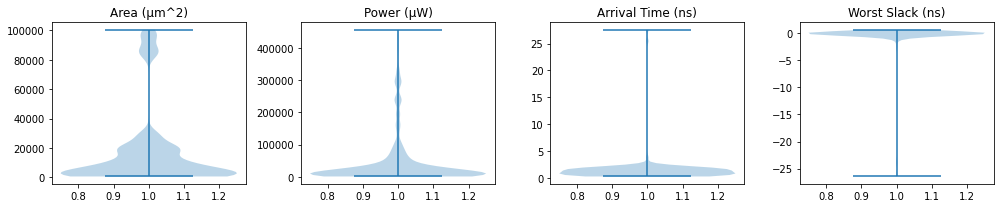

In [14]:
# Metrics to plot
columns = ["total_area", "total_power", "worst_arrival_time", "worst_slack"]
labels = ["Area (µm^2)", "Power (µW)", "Arrival Time (ns)", "Worst Slack (ns)"]

# Create figure
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

# (a) Complete dataset
for i, (col, label) in enumerate(zip(columns, labels)):
    axes[i].violinplot(df[col])
    axes[i].set_title(label)

plt.tight_layout()
plt.show()

Analyzing parameter sensitivity...
Parameters: ['clock_class', 'aspect_ratio', 'core_utilization', 'place_density']
QoR Metrics: ['total_area', 'total_power', 'worst_slack', 'total_negative_slack']


<ipython-input-15-7b5f61a0a9d1>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(param)[metric].mean()
<ipython-input-15-7b5f61a0a9d1>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(param)[metric].mean()
<ipython-input-15-7b5f61a0a9d1>:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(param)[metric].mean()
<ipython-input-15-7b5f61a0a9d1>:21: FutureWarning

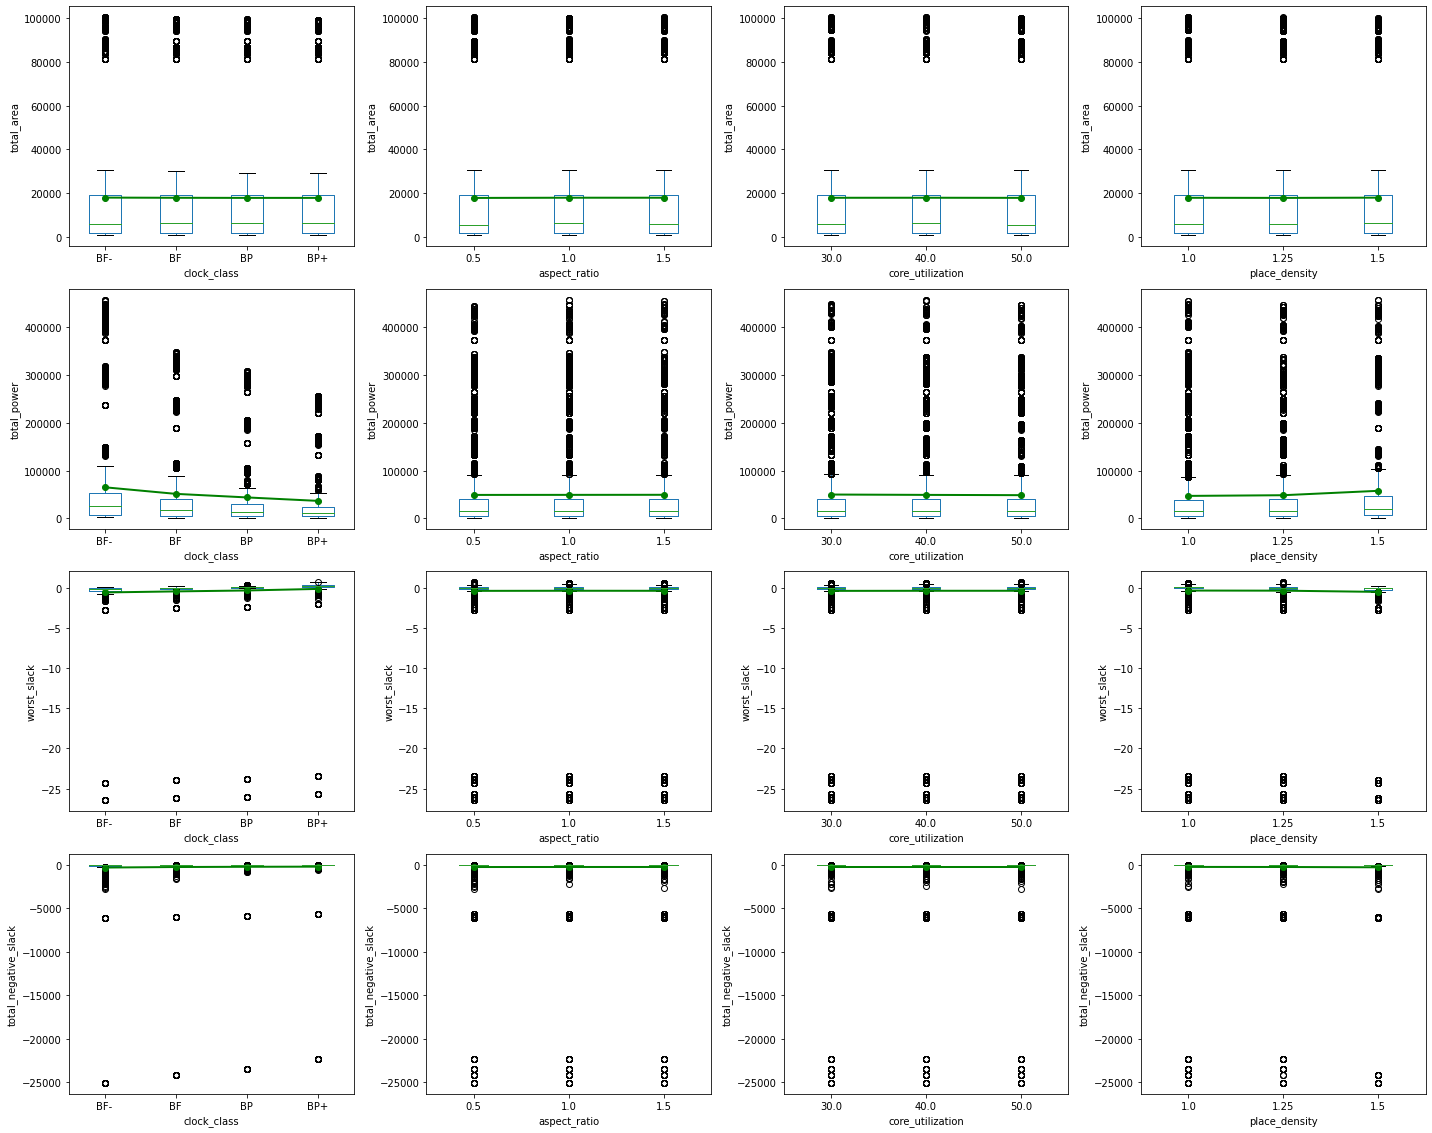

In [15]:
# Define parameters and metrics for sensitivity analysis
parameters = ["clock_class", "aspect_ratio", "core_utilization", "place_density"]
qor_metrics = ["total_area", "total_power", "worst_slack", "total_negative_slack"]
metric_labels = ["Total Area (µm²)", "Total Power (µW)", "Worst Slack (ns)", "Total Negative Slack (ns)"]

print("Analyzing parameter sensitivity...")
print(f"Parameters: {parameters}")
print(f"QoR Metrics: {qor_metrics}")

# Create comprehensive sensitivity plots
fig, axes = plt.subplots(len(qor_metrics), len(parameters), figsize=(20, 16))

for i, metric in enumerate(qor_metrics):
    for j, param in enumerate(parameters):
        ax = axes[i, j]

        # Box plot
        df.boxplot(column=metric, by=param, ax=ax, grid=False)

        # Compute means per parameter value
        grouped = df.groupby(param)[metric].mean()

        # X positions must match boxplot positions (1..N)
        x = np.arange(1, len(grouped) + 1)

        # Green mean trend line
        ax.plot(x, grouped.values, color="green", marker="o", linewidth=2)

        ax.set_title("")
        ax.set_xlabel(param)
        ax.set_ylabel(metric)

plt.suptitle("")
plt.tight_layout()
plt.show()

In [16]:
# Quantitative sensitivity analysis using correlation
print("Computing parameter-metric correlations...")

# Prepare data for correlation analysis
correlation_records = []

# Convert categorical parameters to numeric for correlation
corr_df = df.copy()
clock_class_mapping = {"BF-": 1, "BF": 2, "BP": 3, "BP+": 4}
corr_df["clock_class_numeric"] = corr_df["clock_class"].map(clock_class_mapping)

# Parameters for correlation (use numeric versions)
corr_params = ["clock_class_numeric", "aspect_ratio", "core_utilization", "place_density"]
corr_param_labels = ["Clock Class", "Aspect Ratio", "Core Utilization", "Placement Density"]

# Compute correlations per design
for design_name, group in corr_df.groupby("design"):
    for param, param_label in zip(corr_params, corr_param_labels):
        for metric, metric_label in zip(qor_metrics, metric_labels):
            if group[param].nunique() > 1 and group[metric].nunique() > 1:
                try:
                    r = group[[param, metric]].corr().iloc[0, 1]
                    correlation_records.append({
                        "design": design_name,
                        "parameter": param_label,
                        "metric": metric_label,
                        "pearson_r": r,
                        "abs_correlation": abs(r)
                    })
                except:
                    continue

# Create correlation DataFrame
correlation_df = pd.DataFrame(correlation_records)

print(f"✅ Computed {len(correlation_df)} parameter-metric correlations")
print(f"Across {correlation_df['design'].nunique()} designs")

# Display correlation summary
if not correlation_df.empty:
    corr_summary = (
        correlation_df.groupby(["parameter", "metric"])["pearson_r"]
        .agg(["mean", "std", "min", "max", "count"])
        .round(3)
    )
    
    print("\n📊 Parameter-Metric Correlation Summary")
    display(corr_summary)

Computing parameter-metric correlations...
✅ Computed 288 parameter-metric correlations
Across 18 designs

📊 Parameter-Metric Correlation Summary


mean    std    min    max  count
parameter         metric                                                      
Aspect Ratio      Total Area (µm²)          -0.002  0.014 -0.045  0.018     18
                  Total Negative Slack (ns)  0.001  0.010 -0.027  0.027     18
                  Total Power (µW)           0.002  0.008 -0.015  0.015     18
                  Worst Slack (ns)          -0.001  0.022 -0.078  0.025     18
Clock Class       Total Area (µm²)          -0.202  0.124 -0.406  0.008     18
                  Total Negative Slack (ns)  0.460  0.255  0.025  0.830     18
                  Total Power (µW)          -0.853  0.081 -0.951 -0.683     18
                  Worst Slack (ns)           0.663  0.314  0.028  0.995     18
Core Utilization  Total Area (µm²)          -0.062  0.044 -0.186  0.008     18
                  Total Negative Slack (ns)  0.007  0.010 -0.014  0.025     18
                  Total Power (µW)          -0.038  0.020 -0.067 -0.002     18
                  Worst Slack (ns)           0.019  0.021 -0.014  0.088     18
Placement Density Total Area (µm²)           0.043  0.074 -0.152  0.173     18
                  Total Negative Slack (ns) -0.173  0.099 -0.313 -0.008     18
                  Total Power (µW)           0.294  0.033  0.205  0.334     18
                  Worst Slack (ns)          -0.220  0.112 -0.352 -0.006     18

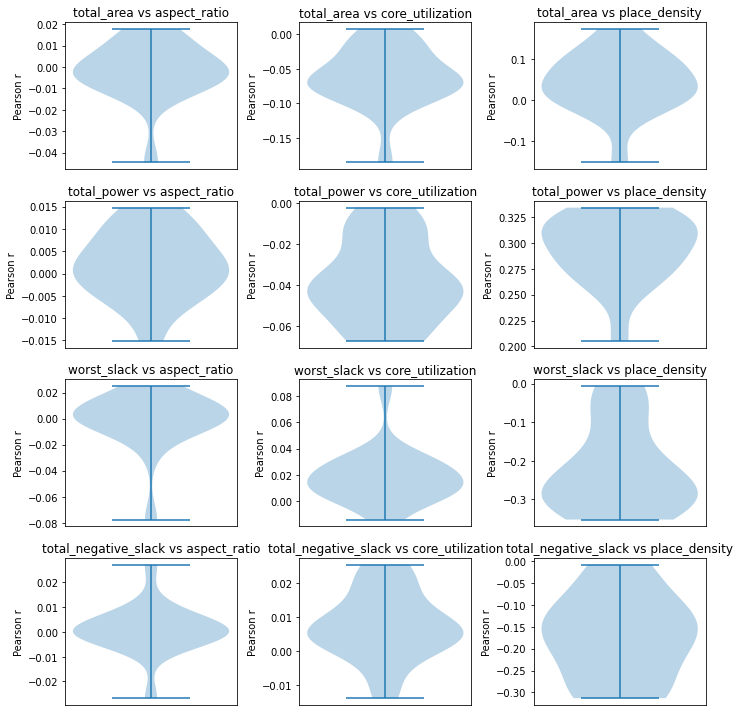

In [17]:
# Parameters and QoR metrics
parameters = ["aspect_ratio", "core_utilization", "place_density"]
metrics = ["total_area", "total_power", "worst_slack", "total_negative_slack"]

# Compute Pearson correlation per circuit
records = []
for design, g in df.groupby("design"):
    for param in parameters:
        for metric in metrics:
            if g[param].nunique() > 1 and g[metric].nunique() > 1:
                r = g[[param, metric]].corr().iloc[0, 1]
                records.append({
                    "design": design,
                    "parameter": param,
                    "metric": metric,
                    "pearson_r": r
                })

corr_df = pd.DataFrame(records)

# Plot distribution of Pearson coefficients
fig, axes = plt.subplots(
    len(metrics),
    len(parameters),
    figsize=(10, 10),
)

for i, metric in enumerate(metrics):
    for j, param in enumerate(parameters):
        ax = axes[i, j]
        data = corr_df[
            (corr_df["metric"] == metric) &
            (corr_df["parameter"] == param)
        ]["pearson_r"].dropna()

        ax.violinplot(data)
#         ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_xticks([])
        ax.set_ylabel("Pearson r")
        ax.set_title(f"{metric} vs {param}")

plt.tight_layout()
plt.show()